# Python-callback proton-impact source simulations

This notebook runs the prototype Python callback source one case at a time. It redirects WarpX output to log files to keep JupyterLab responsive. The callback is for validation and method development; use the seeded model or C++ MCC patch for large production runs.

In [1]:
from pathlib import Path
import os
import sys
import subprocess
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

WORK = Path.home() / "Work" / "simulation_codes-working"
WARPX_DATA_DIR = WORK / "warpx-data"
SCRIPT = Path("plasma_column_callback_source_picmi_v3.py").resolve()

os.environ["WARPX_DATA_DIR"] = str(WARPX_DATA_DIR)
os.environ["LD_LIBRARY_PATH"] = (
    "/home/cspark/Work/simulation_codes-working/warpx/install/lib:"
    + os.environ.get("LD_LIBRARY_PATH", "")
)

print("Python:", sys.executable)
print("Script:", SCRIPT)
print("WarpX data:", WARPX_DATA_DIR)


Python: /home/cspark/Work/simulation_codes-working/miniforge3/envs/warpx-dev/bin/python
Script: /home/cspark/Work/projects/plasma_column/simulations/plasma_column_callback_source_picmi_v3.py
WarpX data: /home/cspark/Work/simulation_codes-working/warpx-data


## 1. Check required files

In [2]:
subprocess.run(
    [sys.executable, "-c", "from pywarpx import picmi; print('pywarpx OK')"],
    check=True,
    env=os.environ.copy(),
)

for gas in ["H2", "Kr"]:
    p = WARPX_DATA_DIR / "MCC_cross_sections" / gas / "proton_impact_ionization.dat"
    print(gas, p, "OK" if p.exists() else "MISSING")


pywarpx OK
H2 /home/cspark/Work/simulation_codes-working/warpx-data/MCC_cross_sections/H2/proton_impact_ionization.dat OK
Kr /home/cspark/Work/simulation_codes-working/warpx-data/MCC_cross_sections/Kr/proton_impact_ionization.dat OK


## 2. Run configuration

Start with short validation runs. Do **not** jump to 120000 steps with the Python callback before checking particle growth.

In [3]:
# Suggested 20k validation settings. Copy these into common_args above when ready.
suggested_20k_common_args = [
    "--warpx_data_dir", str(WARPX_DATA_DIR),
    "--pressure_torr", "1e-5",
    "--max_steps", "20000",
    "--diag_period", "5000",
    "--reduced_diag_period", "100",
    "--reduced_diag_dir", "reducedfiles/",
    "--nx", "24", "--ny", "24", "--nz", "128",
    "--source_every_n_steps", "100",
    "--source_weight_min", "1.0e5",
]
suggested_20k_common_args


['--warpx_data_dir',
 '/home/cspark/Work/simulation_codes-working/warpx-data',
 '--pressure_torr',
 '1e-5',
 '--max_steps',
 '20000',
 '--diag_period',
 '5000',
 '--reduced_diag_period',
 '100',
 '--reduced_diag_dir',
 'reducedfiles/',
 '--nx',
 '24',
 '--ny',
 '24',
 '--nz',
 '128',
 '--source_every_n_steps',
 '100',
 '--source_weight_min',
 '1.0e5']

In [4]:
# Smoke/validation settings. Increase max_steps gradually after checking particle growth.
common_args = [
    "--warpx_data_dir", str(WARPX_DATA_DIR),
    "--pressure_torr", "1e-5",
    "--max_steps", "2000",
    "--diag_period", "500",
    "--reduced_diag_period", "10",
    "--reduced_diag_dir", "reducedfiles/",
    "--nx", "24", "--ny", "24", "--nz", "128",
    "--source_every_n_steps", "10",
    "--source_weight_min", "1.0e4",
]

common_args = suggested_20k_common_args

common_args

['--warpx_data_dir',
 '/home/cspark/Work/simulation_codes-working/warpx-data',
 '--pressure_torr',
 '1e-5',
 '--max_steps',
 '20000',
 '--diag_period',
 '5000',
 '--reduced_diag_period',
 '100',
 '--reduced_diag_dir',
 'reducedfiles/',
 '--nx',
 '24',
 '--ny',
 '24',
 '--nz',
 '128',
 '--source_every_n_steps',
 '100',
 '--source_weight_min',
 '1.0e5']

In [5]:
cases = [
    {
        "name": "callback_H2_20k",
        "args": ["--gas", "H2", "--enable_ionization_source", "1"],
    },
    {
        "name": "callback_Kr_20k",
        "args": ["--gas", "Kr", "--enable_ionization_source", "1"],
    },
    {
        "name": "callback_vacuum_20k",
        "args": ["--gas", "H2", "--enable_ionization_source", "0"],
    },
]
cases

[{'name': 'callback_H2_2k',
  'args': ['--gas', 'H2', '--enable_ionization_source', '1']},
 {'name': 'callback_Kr_2k',
  'args': ['--gas', 'Kr', '--enable_ionization_source', '1']},
 {'name': 'callback_vacuum_2k',
  'args': ['--gas', 'H2', '--enable_ionization_source', '0']}]

## 3. Helpers

In [6]:
def run_case(case):
    out_dir = Path("runs") / case["name"]
    out_dir.mkdir(parents=True, exist_ok=True)
    log_dir = Path("logs")
    log_dir.mkdir(exist_ok=True)
    log_file = log_dir / f"{case['name']}.log"

    cmd = [
        sys.executable, str(SCRIPT),
        "--run",
        "--output_dir", str(out_dir),
    ] + common_args + case["args"]

    print("=" * 90)
    print("Running:", case["name"])
    print("Output:", out_dir)
    print("Log:", log_file)
    print("Command:")
    print(" ".join(cmd))
    print("=" * 90)

    t0 = time.time()
    with log_file.open("w") as lf:
        result = subprocess.run(
            cmd,
            stdout=lf,
            stderr=subprocess.STDOUT,
            env=os.environ.copy(),
            text=True,
        )
    elapsed = time.time() - t0

    print(f"Return code: {result.returncode}")
    print(f"Elapsed: {elapsed/60:.2f} min")
    print("\n--- log tail ---")
    print("\n".join(log_file.read_text(errors="replace").splitlines()[-50:]))

    if result.returncode != 0:
        raise RuntimeError(f"Case failed: {case['name']}. See {log_file}")

    return out_dir, log_file


def check_case_outputs(case_name):
    out_dir = Path("runs") / case_name
    targets = [
        out_dir / "callback_neutralization_from_particle_number.csv",
        out_dir / "neutralization_source_model.csv",
        out_dir / "reducedfiles" / "particle_number.txt",
        out_dir / "reducedfiles" / "timestep.txt",
    ]
    print("\nCASE:", case_name)
    ok = True
    for p in targets:
        exists = p.exists()
        print(f"  {p}: {'OK' if exists else 'MISSING'}")
        ok = ok and exists
    return ok


def load_callback_history(case_name):
    out_dir = Path("runs") / case_name
    hist = pd.read_csv(out_dir / "callback_neutralization_from_particle_number.csv")
    model = pd.read_csv(out_dir / "neutralization_source_model.csv")
    return hist, model


## 4. Run callback cases one by one

In [7]:
# Recommended first run:
out_dir, log_file = run_case(cases[0])  # callback_H2_2k
check_case_outputs(cases[0]["name"])


Running: callback_H2_2k
Output: runs/callback_H2_2k
Log: logs/callback_H2_2k.log
Command:
/home/cspark/Work/simulation_codes-working/miniforge3/envs/warpx-dev/bin/python /home/cspark/Work/projects/plasma_column/simulations/plasma_column_callback_source_picmi_v3.py --run --output_dir runs/callback_H2_2k --warpx_data_dir /home/cspark/Work/simulation_codes-working/warpx-data --pressure_torr 1e-5 --max_steps 20000 --diag_period 5000 --reduced_diag_period 100 --reduced_diag_dir reducedfiles/ --nx 24 --ny 24 --nz 128 --source_every_n_steps 100 --source_weight_min 1.0e5 --gas H2 --enable_ionization_source 1
Return code: 0
Elapsed: 97.29 min

--- log tail ---
amrex::Copy()                                                         903690      50.21      50.21      50.21   0.86%
FabArray::setVal()                                                    782508       48.2       48.2       48.2   0.83%
MultiFab::Copy()                                                      542460      39.12      39.12      

True

In [8]:
# Then run Kr:
out_dir, log_file = run_case(cases[1])  # callback_Kr_2k
check_case_outputs(cases[1]["name"])


Running: callback_Kr_2k
Output: runs/callback_Kr_2k
Log: logs/callback_Kr_2k.log
Command:
/home/cspark/Work/simulation_codes-working/miniforge3/envs/warpx-dev/bin/python /home/cspark/Work/projects/plasma_column/simulations/plasma_column_callback_source_picmi_v3.py --run --output_dir runs/callback_Kr_2k --warpx_data_dir /home/cspark/Work/simulation_codes-working/warpx-data --pressure_torr 1e-5 --max_steps 20000 --diag_period 5000 --reduced_diag_period 100 --reduced_diag_dir reducedfiles/ --nx 24 --ny 24 --nz 128 --source_every_n_steps 100 --source_weight_min 1.0e5 --gas Kr --enable_ionization_source 1
Return code: 0
Elapsed: 128.07 min

--- log tail ---
PhysicalParticleContainer::PushP()                                      1200      66.82      66.82      66.82   0.87%
FabArray::FillBoundaryAndSync()                                       240000      63.91      63.91      63.91   0.83%
WarpX::EvolveE()                                                       20000      57.07      57.07     

True

In [9]:
# Optional vacuum control:
out_dir, log_file = run_case(cases[2])  # callback_vacuum_2k
check_case_outputs(cases[2]["name"])


Running: callback_vacuum_2k
Output: runs/callback_vacuum_2k
Log: logs/callback_vacuum_2k.log
Command:
/home/cspark/Work/simulation_codes-working/miniforge3/envs/warpx-dev/bin/python /home/cspark/Work/projects/plasma_column/simulations/plasma_column_callback_source_picmi_v3.py --run --output_dir runs/callback_vacuum_2k --warpx_data_dir /home/cspark/Work/simulation_codes-working/warpx-data --pressure_torr 1e-5 --max_steps 20000 --diag_period 5000 --reduced_diag_period 100 --reduced_diag_dir reducedfiles/ --nx 24 --ny 24 --nz 128 --source_every_n_steps 100 --source_weight_min 1.0e5 --gas H2 --enable_ionization_source 0
Return code: 0
Elapsed: 99.99 min

--- log tail ---
PhysicalParticleContainer::PushP()                                      1200      55.35      55.35      55.35   0.92%
amrex::Copy()                                                         903690      52.17      52.17      52.17   0.87%
FabArray::setVal()                                                    782508      51.52 

True

## 5. Diagnostics plots

In [10]:
completed_cases = [c["name"] for c in cases if check_case_outputs(c["name"])]
completed_cases



CASE: callback_H2_2k
  runs/callback_H2_2k/callback_neutralization_from_particle_number.csv: OK
  runs/callback_H2_2k/neutralization_source_model.csv: OK
  runs/callback_H2_2k/reducedfiles/particle_number.txt: OK
  runs/callback_H2_2k/reducedfiles/timestep.txt: OK

CASE: callback_Kr_2k
  runs/callback_Kr_2k/callback_neutralization_from_particle_number.csv: OK
  runs/callback_Kr_2k/neutralization_source_model.csv: OK
  runs/callback_Kr_2k/reducedfiles/particle_number.txt: OK
  runs/callback_Kr_2k/reducedfiles/timestep.txt: OK

CASE: callback_vacuum_2k
  runs/callback_vacuum_2k/callback_neutralization_from_particle_number.csv: OK
  runs/callback_vacuum_2k/neutralization_source_model.csv: OK
  runs/callback_vacuum_2k/reducedfiles/particle_number.txt: OK
  runs/callback_vacuum_2k/reducedfiles/timestep.txt: OK


['callback_H2_2k', 'callback_Kr_2k', 'callback_vacuum_2k']

In [11]:
histories = {}
models = {}
for name in completed_cases:
    hist, model = load_callback_history(name)
    histories[name] = hist
    models[name] = model
    print("\n", name)
    display(hist.head())
    display(hist.tail())



 callback_H2_2k


,step,time_s,macro_total,macro_beam_protons,macro_plasma_electrons,macro_gas_ions,physical_total,physical_beam_protons,physical_plasma_electrons,physical_gas_ions,electron_over_proton,ion_over_proton,global_net_neutralization
0,0,0.000000e+00,8034.0,0.0,4009.0,4025.0,1.133268e-05,0.000000e+00,0.000006,0.000006,NaN,NaN,NaN
1,100,1.321403e-10,15248.0,7214.0,4009.0,4025.0,8.219942e+06,8.219942e+06,0.000006,0.000006,6.879679e-13,6.907136e-13,-2.745694e-15
2,200,2.642807e-10,22476.0,14442.0,4009.0,4025.0,1.645584e+07,1.645584e+07,0.000006,0.000006,3.436505e-13,3.450220e-13,-1.371516e-15
3,300,3.964210e-10,29705.0,21671.0,4009.0,4025.0,2.469287e+07,2.469287e+07,0.000006,0.000006,2.290158e-13,2.299298e-13,-9.140065e-16
4,400,5.285613e-10,36922.0,28888.0,4009.0,4025.0,3.291623e+07,3.291623e+07,0.000006,0.000006,1.718015e-13,1.724871e-13,-6.856631e-16


,step,time_s,macro_total,macro_beam_protons,macro_plasma_electrons,macro_gas_ions,physical_total,physical_beam_protons,physical_plasma_electrons,physical_gas_ions,electron_over_proton,ion_over_proton,global_net_neutralization
196,19600,2.589950e-08,1427059.0,1419025.0,4009.0,4025.0,1.616898e+09,1.616898e+09,0.000006,0.000006,3.497472e-15,3.511431e-15,-1.395848e-17
197,19700,2.603164e-08,1434260.0,1426226.0,4009.0,4025.0,1.625103e+09,1.625103e+09,0.000006,0.000006,3.479813e-15,3.493701e-15,-1.388801e-17
198,19800,2.616378e-08,1441489.0,1433455.0,4009.0,4025.0,1.633340e+09,1.633340e+09,0.000006,0.000006,3.462265e-15,3.476083e-15,-1.381797e-17
199,19900,2.629592e-08,1448713.0,1440679.0,4009.0,4025.0,1.641572e+09,1.641572e+09,0.000006,0.000006,3.444904e-15,3.458652e-15,-1.374868e-17
200,20000,2.642807e-08,1455931.0,1447897.0,4009.0,4025.0,1.649796e+09,1.649796e+09,0.000006,0.000006,3.427730e-15,3.441410e-15,-1.368014e-17



 callback_Kr_2k


,step,time_s,macro_total,macro_beam_protons,macro_plasma_electrons,macro_gas_ions,physical_total,physical_beam_protons,physical_plasma_electrons,physical_gas_ions,electron_over_proton,ion_over_proton,global_net_neutralization
0,0,0.000000e+00,8008.0,0.0,4002.0,4006.0,1.129601e-05,0.000000e+00,0.000006,0.000006,NaN,NaN,NaN
1,100,1.321403e-10,15238.0,7230.0,4002.0,4006.0,8.238173e+06,8.238173e+06,0.000006,0.000006,6.852468e-13,6.859317e-13,-6.849044e-16
2,200,2.642807e-10,22455.0,14447.0,4002.0,4006.0,1.646153e+07,1.646153e+07,0.000006,0.000006,3.429317e-13,3.432745e-13,-3.427603e-16
3,300,3.964210e-10,29700.0,21692.0,4002.0,4006.0,2.471680e+07,2.471680e+07,0.000006,0.000006,2.283946e-13,2.286228e-13,-2.282804e-16
4,400,5.285613e-10,36946.0,28938.0,4002.0,4006.0,3.297320e+07,3.297320e+07,0.000006,0.000006,1.712052e-13,1.713763e-13,-1.711196e-16


,step,time_s,macro_total,macro_beam_protons,macro_plasma_electrons,macro_gas_ions,physical_total,physical_beam_protons,physical_plasma_electrons,physical_gas_ions,electron_over_proton,ion_over_proton,global_net_neutralization
196,19600,2.589950e-08,1426751.0,1418743.0,4002.0,4006.0,1.616577e+09,1.616577e+09,0.000006,0.000006,3.492059e-15,3.495550e-15,-3.490314e-18
197,19700,2.603164e-08,1433961.0,1425953.0,4002.0,4006.0,1.624792e+09,1.624792e+09,0.000006,0.000006,3.474402e-15,3.477875e-15,-3.472666e-18
198,19800,2.616378e-08,1441188.0,1433180.0,4002.0,4006.0,1.633027e+09,1.633027e+09,0.000006,0.000006,3.456882e-15,3.460338e-15,-3.455155e-18
199,19900,2.629592e-08,1448402.0,1440394.0,4002.0,4006.0,1.641247e+09,1.641247e+09,0.000006,0.000006,3.439569e-15,3.443007e-15,-3.437850e-18
200,20000,2.642807e-08,1455634.0,1447626.0,4002.0,4006.0,1.649487e+09,1.649487e+09,0.000006,0.000006,3.422386e-15,3.425806e-15,-3.420675e-18



 callback_vacuum_2k


,step,time_s,macro_total,macro_beam_protons,macro_plasma_electrons,macro_gas_ions,physical_total,physical_beam_protons,physical_plasma_electrons,physical_gas_ions,electron_over_proton,ion_over_proton,global_net_neutralization
0,0,0.000000e+00,7984.0,0.0,3973.0,4011.0,1.126215e-05,0.000000e+00,0.000006,0.000006,NaN,NaN,NaN
1,100,1.321403e-10,15227.0,7243.0,3973.0,4011.0,8.252986e+06,8.252986e+06,0.000006,0.000006,6.790603e-13,6.855552e-13,-6.494913e-15
2,200,2.642807e-10,22467.0,14483.0,3973.0,4011.0,1.650255e+07,1.650255e+07,0.000006,0.000006,3.396005e-13,3.428486e-13,-3.248129e-15
3,300,3.964210e-10,29712.0,21728.0,3973.0,4011.0,2.475782e+07,2.475782e+07,0.000006,0.000006,2.263638e-13,2.285289e-13,-2.165071e-15
4,400,5.285613e-10,36958.0,28974.0,3973.0,4011.0,3.301422e+07,3.301422e+07,0.000006,0.000006,1.697534e-13,1.713770e-13,-1.623616e-15


,step,time_s,macro_total,macro_beam_protons,macro_plasma_electrons,macro_gas_ions,physical_total,physical_beam_protons,physical_plasma_electrons,physical_gas_ions,electron_over_proton,ion_over_proton,global_net_neutralization
196,19600,2.589950e-08,1426763.0,1418779.0,3973.0,4011.0,1.616618e+09,1.616618e+09,0.000006,0.000006,3.466667e-15,3.499824e-15,-3.315714e-17
197,19700,2.603164e-08,1433973.0,1425989.0,3973.0,4011.0,1.624833e+09,1.624833e+09,0.000006,0.000006,3.449139e-15,3.482128e-15,-3.298950e-17
198,19800,2.616378e-08,1441200.0,1433216.0,3973.0,4011.0,1.633068e+09,1.633068e+09,0.000006,0.000006,3.431746e-15,3.464569e-15,-3.282315e-17
199,19900,2.629592e-08,1448414.0,1440430.0,3973.0,4011.0,1.641288e+09,1.641288e+09,0.000006,0.000006,3.414559e-15,3.447218e-15,-3.265876e-17
200,20000,2.642807e-08,1455646.0,1447662.0,3973.0,4011.0,1.649528e+09,1.649528e+09,0.000006,0.000006,3.397501e-15,3.429997e-15,-3.249561e-17


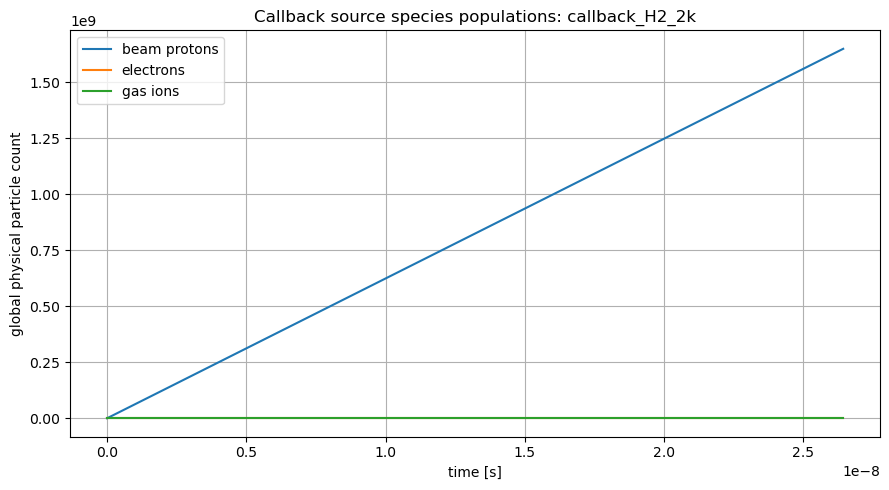

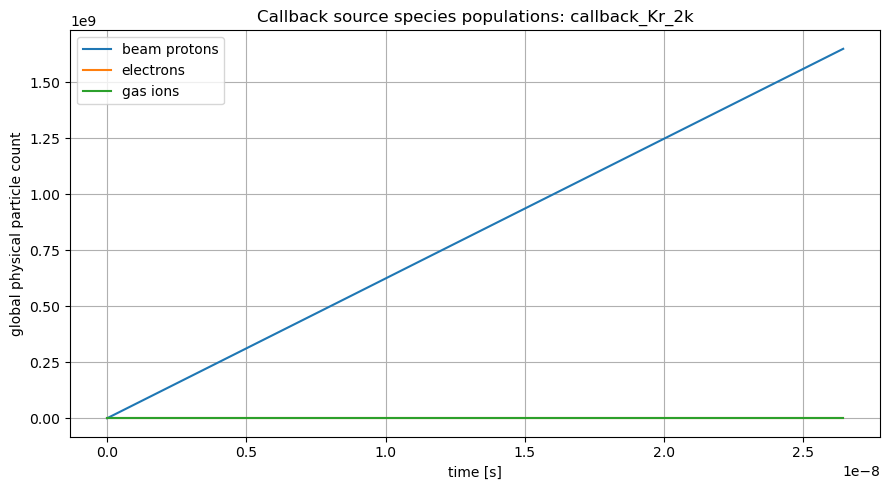

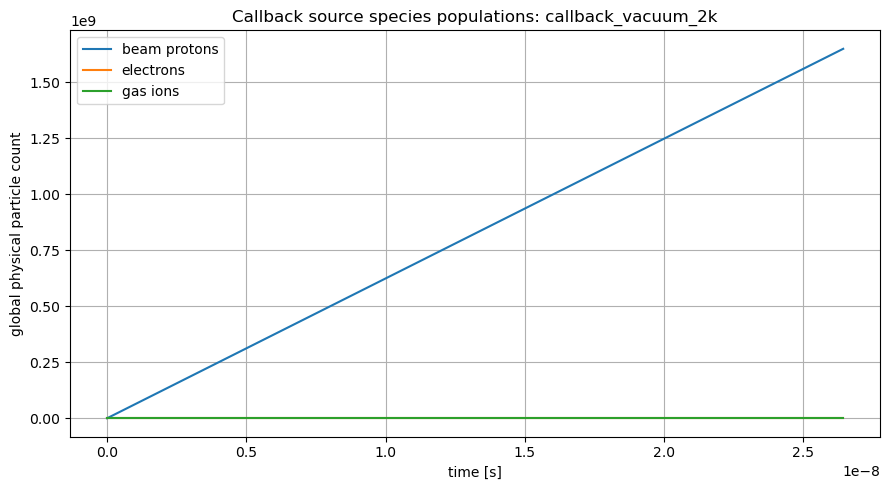

In [12]:
# Source-produced species histories.
for name, hist in histories.items():
    plt.figure(figsize=(9,5))
    plt.plot(hist["time_s"], hist["physical_beam_protons"], label="beam protons")
    plt.plot(hist["time_s"], hist["physical_plasma_electrons"], label="electrons")
    plt.plot(hist["time_s"], hist["physical_gas_ions"], label="gas ions")
    plt.xlabel("time [s]")
    plt.ylabel("global physical particle count")
    plt.title(f"Callback source species populations: {name}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


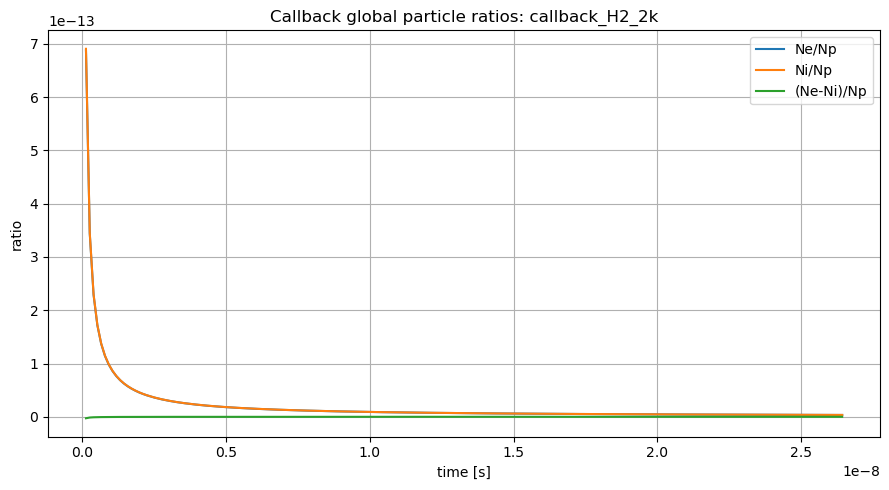

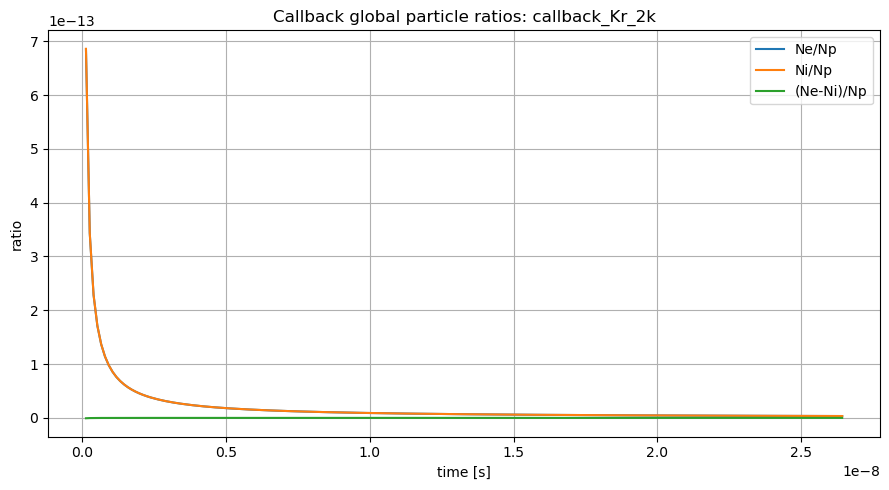

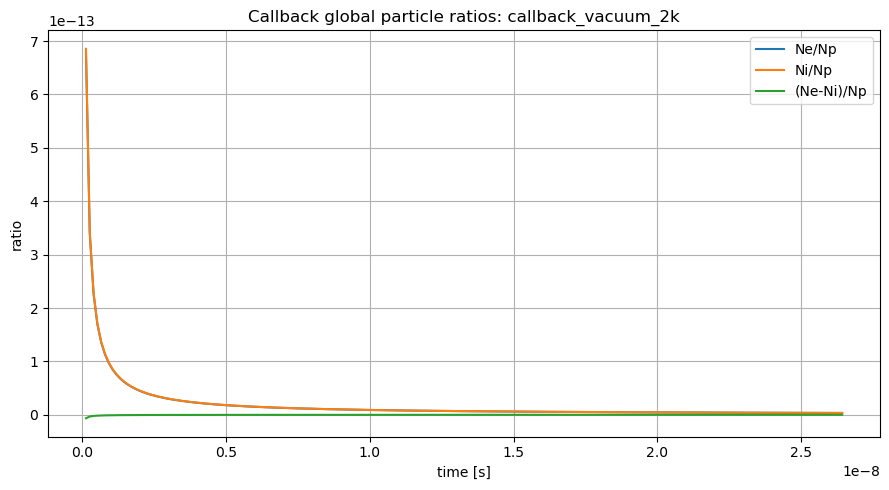

In [13]:
# Global neutralization ratios from particle counts.
for name, hist in histories.items():
    plt.figure(figsize=(9,5))
    plt.plot(hist["time_s"], hist["electron_over_proton"], label="Ne/Np")
    plt.plot(hist["time_s"], hist["ion_over_proton"], label="Ni/Np")
    plt.plot(hist["time_s"], hist["global_net_neutralization"], label="(Ne-Ni)/Np")
    plt.xlabel("time [s]")
    plt.ylabel("ratio")
    plt.title(f"Callback global particle ratios: {name}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


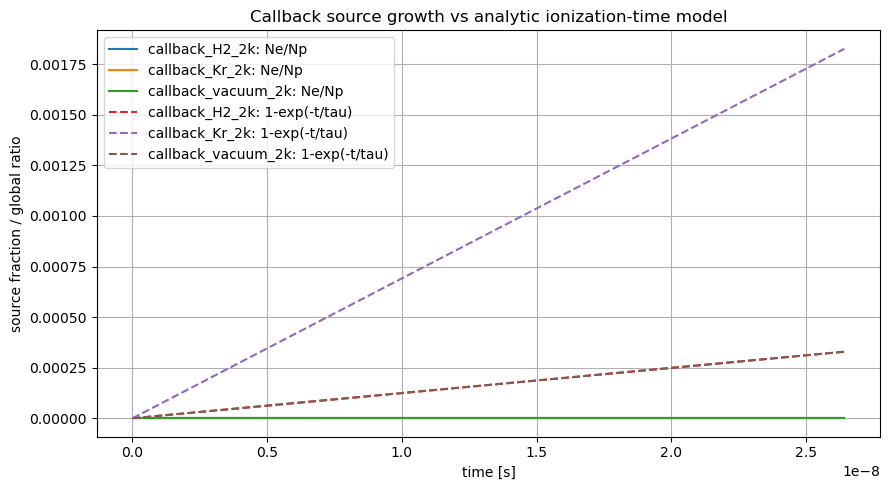

In [14]:
# Compare source integral model against particle-count electron growth.
plt.figure(figsize=(9,5))
for name, hist in histories.items():
    if len(hist) > 0:
        # This is a global count ratio, not a local neutralization.
        plt.plot(hist["time_s"], hist["electron_over_proton"], label=f"{name}: Ne/Np")
for name, model in models.items():
    plt.plot(
        model["t_est_s"],
        model["source_integral_fraction_1_minus_exp"],
        "--",
        label=f"{name}: 1-exp(-t/tau)",
    )
plt.xlabel("time [s]")
plt.ylabel("source fraction / global ratio")
plt.title("Callback source growth vs analytic ionization-time model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 6. Scaling to longer runs

Only after the 2k-step cases look stable, try 20k. For 120k, the Python callback can become expensive because it creates new macroparticles. Prefer seeded or C++ MCC for final production runs.

In [15]:
# Suggested 20k validation settings. Copy these into common_args above when ready.
suggested_20k_common_args = [
    "--warpx_data_dir", str(WARPX_DATA_DIR),
    "--pressure_torr", "1e-5",
    "--max_steps", "20000",
    "--diag_period", "5000",
    "--reduced_diag_period", "100",
    "--reduced_diag_dir", "reducedfiles/",
    "--nx", "24", "--ny", "24", "--nz", "128",
    "--source_every_n_steps", "100",
    "--source_weight_min", "1.0e5",
]
suggested_20k_common_args


['--warpx_data_dir',
 '/home/cspark/Work/simulation_codes-working/warpx-data',
 '--pressure_torr',
 '1e-5',
 '--max_steps',
 '20000',
 '--diag_period',
 '5000',
 '--reduced_diag_period',
 '100',
 '--reduced_diag_dir',
 'reducedfiles/',
 '--nx',
 '24',
 '--ny',
 '24',
 '--nz',
 '128',
 '--source_every_n_steps',
 '100',
 '--source_weight_min',
 '1.0e5']